In [66]:
import os
from datetime import datetime

import pandas as pd
import numpy as np
from pathlib import Path
import json

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline   
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay, confusion_matrix
)
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay, confusion_matrix

from xgboost import XGBClassifier


import matplotlib.pyplot as plt
import plotly.express as px

## Loading Dataset

In [67]:
df = pd.read_csv("../data/raw/conversion_data_train.csv")

## Preprocessing

In [68]:
target = "converted"

X = df.drop(columns=[target])
y = df[target].astype(int)

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

numeric_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    )),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessor, numeric_features),
        ("cat", categorical_preprocessor, categorical_features),
    ]
)

/var/folders/p7/7w66qcfn4yj82k3sbs5fp74h0000gn/T/ipykernel_59066/2754386860.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


## XGBoost

In [69]:
xgb_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", XGBClassifier(
        random_state=0,
        eval_metric="logloss", 
        n_jobs=-1
    ))
])

param_grid = {
    "clf__max_depth": [3, 4, 6],
    "clf__min_child_weight": [1, 2, 4],
    "clf__n_estimators": [200, 400],
    "clf__learning_rate": [0.05, 0.1],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

grid_xgb = GridSearchCV(
    xgb_pipe,
    param_grid=param_grid,
    scoring="f1",     
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True
)

grid_xgb.fit(X_train, y_train)

print("Best params:", grid_xgb.best_params_)
best_xgb = grid_xgb.best_estimator_

Fitting 3 folds for each of 144 candidates, totalling 432 fits
[CV] END clf__colsample_bytree=0.8, clf__learning_rate=0.05, clf__max_depth=3, clf__min_child_weight=1, clf__n_estimators=200, clf__subsample=0.8; total time=   9.8s
[CV] END clf__colsample_bytree=0.8, clf__learning_rate=0.05, clf__max_depth=3, clf__min_child_weight=1, clf__n_estimators=200, clf__subsample=1.0; total time=   9.6s
[CV] END clf__colsample_bytree=0.8, clf__learning_rate=0.05, clf__max_depth=3, clf__min_child_weight=1, clf__n_estimators=200, clf__subsample=1.0; total time=  10.4s
[CV] END clf__colsample_bytree=0.8, clf__learning_rate=0.05, clf__max_depth=3, clf__min_child_weight=1, clf__n_estimators=200, clf__subsample=1.0; total time=  11.0s
[CV] END clf__colsample_bytree=0.8, clf__learning_rate=0.05, clf__max_depth=3, clf__min_child_weight=1, clf__n_estimators=200, clf__subsample=0.8; total time=  11.2s
[CV] END clf__colsample_bytree=0.8, clf__learning_rate=0.05, clf__max_depth=3, clf__min_child_weight=1, clf

## Model evaluation

In [70]:
def evaluate_model(name, pipe, X_test, y_test):
    y_proba = pipe.predict_proba(X_test)[:, 1]
    y_pred = pipe.predict(X_test)
    metrics = {
        "model": name,
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba)
    }
    return metrics, y_pred, y_proba

In [71]:
xgb_metrics, ypred_xgb, yproba_xgb = evaluate_model("XGBoost", best_xgb, X_test, y_test)

,model,f1,precision,recall,roc_auc
0,XGBoost,0.7692,0.8579,0.6972,0.9866


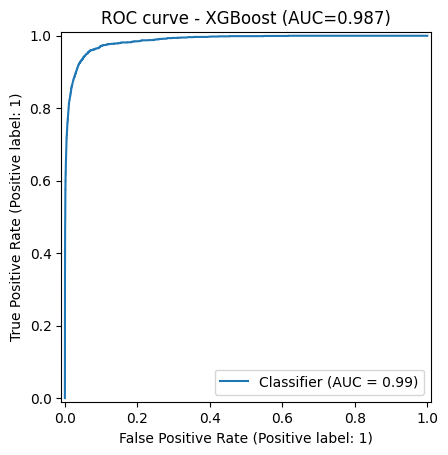

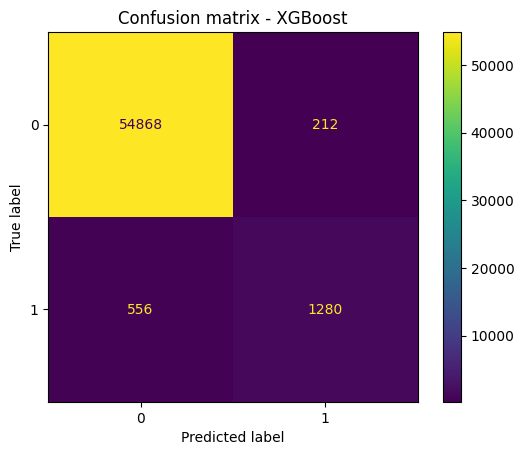

In [72]:
results_df = pd.DataFrame([xgb_metrics])
display(results_df.round(4))

RocCurveDisplay.from_predictions(y_test, yproba_xgb)
plt.title(f"ROC curve - {xgb_metrics['model']} (AUC={xgb_metrics['roc_auc']:.3f})")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, ypred_xgb, values_format="d")
plt.title(f"Confusion matrix - {xgb_metrics['model']}")
plt.show()

## Saving logs

In [73]:
results_path = "../data/logs/model_logs.csv"

os.makedirs(os.path.dirname(results_path), exist_ok=True)

row = xgb_metrics.copy()

row["timestamp"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

columns = [
    "model",
    "f1",
    "precision",
    "recall",
    "roc_auc",
    "timestamp"
]

row_df = pd.DataFrame([row], columns=columns)

if os.path.exists(results_path):
    row_df.to_csv(results_path, mode="a", header=False, index=False)
else:
    row_df.to_csv(results_path, mode="w", header=True, index=False)

print(f"Results appended to {results_path}")

Results appended to ../data/logs/model_logs.csv


## Retraining model on all dataset

In [74]:
target = "converted"
X_full = df.drop(columns=[target])
y_full = df[target].astype(int)

xgb_pipe.fit(X_full, y_full)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

## Loading test dataset

In [75]:
df_unlabeled = pd.read_csv("../data/raw/conversion_data_test.csv")

feature_cols = X_full.columns.tolist()
df_unlabeled = df_unlabeled[feature_cols]

y_proba = xgb_pipe.predict_proba(df_unlabeled)[:, 1]
y_pred  = xgb_pipe.predict(df_unlabeled)

In [76]:
output_file = Path("../data/results/conversion_data_test_predictions_xgboost.csv")
output_file.parent.mkdir(parents=True, exist_ok=True)

submission = pd.DataFrame({"converted": y_pred})
submission.to_csv(output_file, index=False)

## Feature importance analysis

In [77]:
feature_names_cat = (
    best_xgb.named_steps["prep"]
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
)

feature_names_num = numeric_features

feature_names = np.concatenate([
    feature_names_num,
    feature_names_cat
])


importances = best_xgb.named_steps["clf"].feature_importances_


feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feature_importance_df.head(10)

,feature,importance
2,total_pages_visited,0.629491
3,country_China,0.176369
1,new_user,0.127210
6,country_US,0.023774
0,age,0.023640
8,source_Direct,0.006155
4,country_Germany,0.004941
5,country_UK,0.003297
7,source_Ads,0.002975
9,source_Seo,0.002148


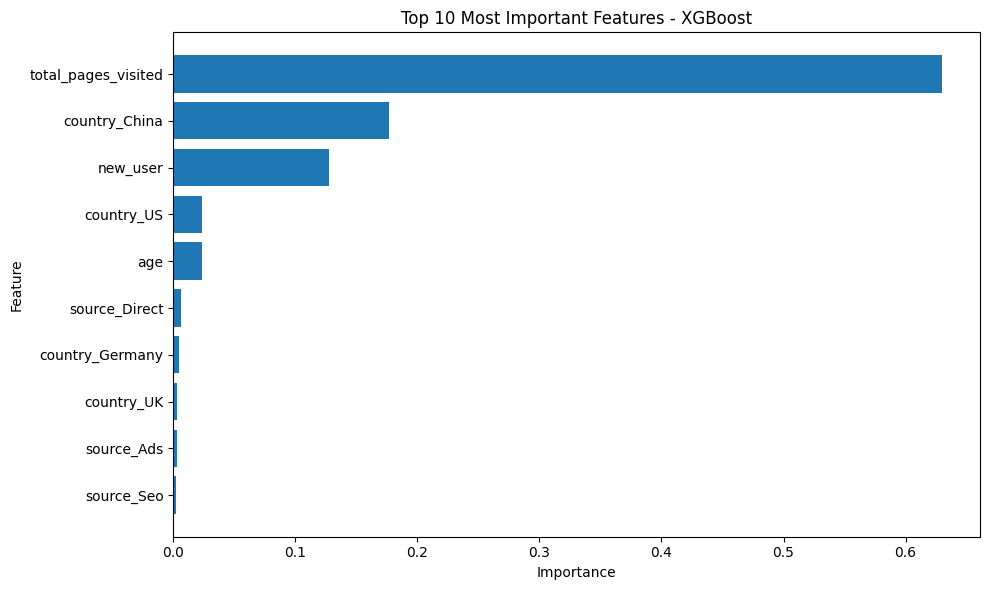

In [78]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_df["feature"].head(10)[::-1],
    feature_importance_df["importance"].head(10)[::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features - XGBoost")

plt.tight_layout()
plt.show()

## Analysis of the XGBoost Model

The XGBoost model highlights a very strong relationship between user engagement and newsletter subscription behavior.

The feature importance analysis shows that `total_pages_visited` is by far the most influential variable in the model. Users who browse more pages are significantly more likely to subscribe to the newsletter. This suggests once again that engagement with the website is the clearest indicator of conversion intent.

The model also reveals that audience characteristics influence conversion probability:

* users from different countries do not behave the same way,
* `country_China` has a noticeably stronger impact than the other country variables,
* new users (`new_user`) show different conversion patterns compared to returning visitors,
* age has a smaller but still measurable effect on subscription behavior.

Other variables such as traffic source (`SEO`, `Ads`, `Direct`) appear to have a relatively limited influence compared to browsing activity.

Overall, the XGBoost model suggests that increasing user engagement on the website should be the main priority for improving conversion rates. Encouraging visitors to explore more content could significantly increase the probability of newsletter subscription.
